# **Import required packages**

There are a number of required Python packages that need to be installed to successfully run the code below. Fortunately, Google Colab already has these packages installed but if you want run this code locally on your computer you would need to make sure the required packages are installed by using running the pip install command below that is correct for your operating system.

**Mac:**
python3 -m pip install numpy matplotlib pandas plotly polars rasterio requests



**Windows:**
python -m pip install matplotlib pandas plotly polars rasterio requests

In [ ]:
!pip install matplotlib-venn

In [ ]:
import io
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import polars as pl
import rasterio
from rasterio.plot import show
import requests
import matplotlib_venn

# **Load datasets to visualize**

In [ ]:
#Portland, Oregon parks tree inventory data from https://gis-pdx.opendata.arcgis.com/datasets/PDX::parks-tree-inventory/about
pdxtreesdf = pd.read_csv("https://hub.arcgis.com/api/v3/datasets/15ae00ece1bf486a868c0f635d3acbfa_220/downloads/data?format=csv&spatialRefId=3857&where=1%3D1")

In [ ]:
#Telco customer churn dataset from https://github.com/IBM/telco-customer-churn-on-icp4d/tree/master
customerchurndf = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv")

In [ ]:
#UAV orthmosaic stored in ArcGIS Online
singleimageband0 = {"bandname":"rgb",  "cmap":"RdBu", "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/7f886ebb895b4610961e076e8eabe092/data"}
singleimageband1 = {"bandname":"blue",  "cmap":"Blues",  "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/ef3529e489da4b489303f357f92d4702/data"}
singleimageband2 = {"bandname":"green",  "cmap":"Greens",  "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/21bfc72d87a844c8834db572bda24e58/data"}
singleimageband3 = {"bandname":"red",  "cmap":"Reds", "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/a88d3b517a4f48d59fc752a259d1e1e1/data"}
singleimageband4 = {"bandname":"rededge",  "cmap":"Greys",  "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/c9b200641847435da1893389b2ecda77/data"}
singleimageband5 = {"bandname":"nir",  "cmap":"Greys",  "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/6450229be3494bd9a4e24283adf8b071/data"}

multibandortho = {"bandname":"all", "cmap":"Greys", "url":"https://ut-austin.maps.arcgis.com/sharing/rest/content/items/7d6bbe91e12641c0b93534ffd038ecd6/data"}

dem = {"bandname":"dem", "cmap":"gist_earth", "url": "https://ut-austin.maps.arcgis.com/sharing/rest/content/items/f735a03cae164f1caeb32de97b017a23/data"}

# **Produce data visualizations**

*   Simple visualization with Pandas
*   Adjust title
*   X and Y label axes
*   Color
*   Saving image in different formats
*   Visualization with Matplotlib
*   Multiple subplots
*   Visualization with Plotly - linear regression




# Save an empty figure

In [ ]:
from matplotlib import pyplot as plt

plt.savefig("example.jpg")

<Figure size 640x480 with 0 Axes>

# Save a figure with an empty plot in it

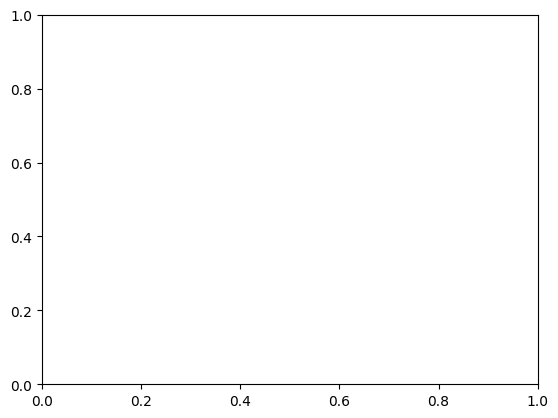

In [ ]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots()
plt.savefig("example.jpg")

# Save a figure with two empty subplots in it

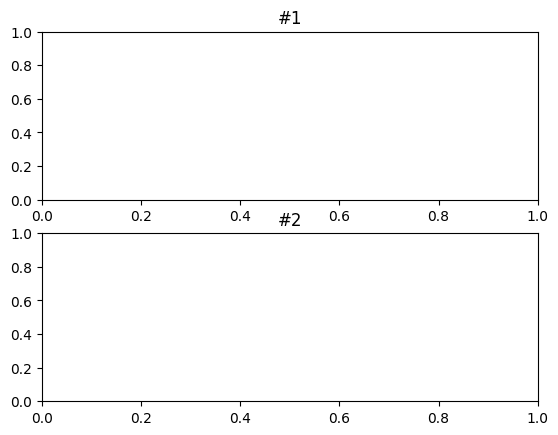

In [ ]:
fig, axs = plt.subplots(2,1)
axs[0].set_title("#1")
axs[1].set_title("#2")
plt.savefig("example.jpg")

# Overwrite the figure and create a scatterplot

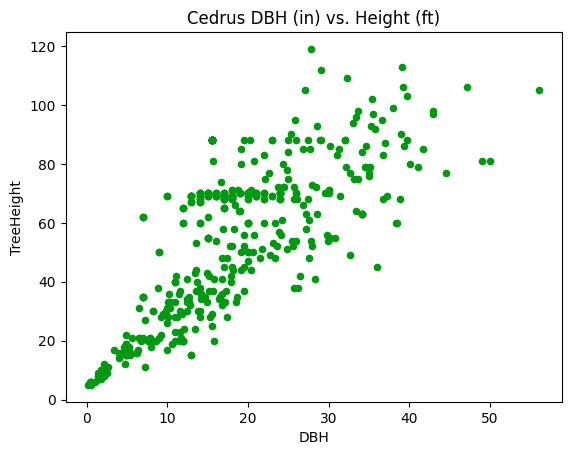

In [ ]:
#clear earlier figure
fig.clear()

#create new figure with 1 subplot
fig, ax = plt.subplots()

#create subset of treesdf that only has data on trees in the genus Calocedrus
cedardf = pdxtreesdf[pdxtreesdf["Genus"] == "Calocedrus"]

#create scatter plot of DBH vs Tree Height for Calocedrus trees
cedardf.plot(kind='scatter', x='DBH', y='TreeHeight', title='Cedrus DBH (in) vs. Height (ft)', color="#009911", ax=ax)
fig.savefig("cedrus.png")

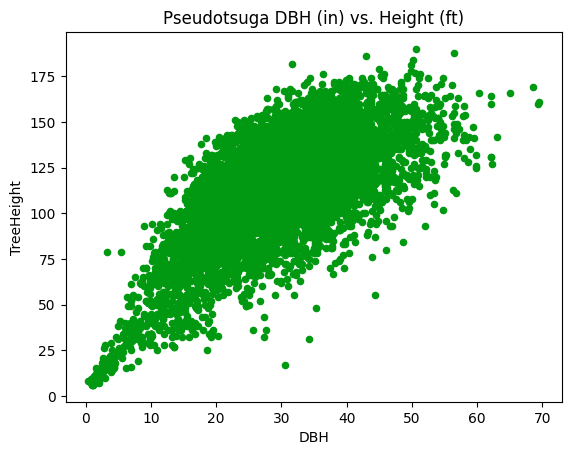

In [ ]:
#clear earlier figure
fig.clear()

#create new figure with 1 subplot
fig, ax = plt.subplots()

#create subset of treesdf that only has data on trees in the genus Pseudotsuga
pseudotsugadf = pdxtreesdf[pdxtreesdf["Genus"] == "Pseudotsuga"]

#create scatter plot of DBH vs Tree Height for Pseudotsuga trees
pseudotsugadf.plot(kind='scatter', x='DBH', y='TreeHeight', title='Pseudotsuga DBH (in) vs. Height (ft)', color="#009911", ax=ax)
plt.savefig("pseudotsuga.png")

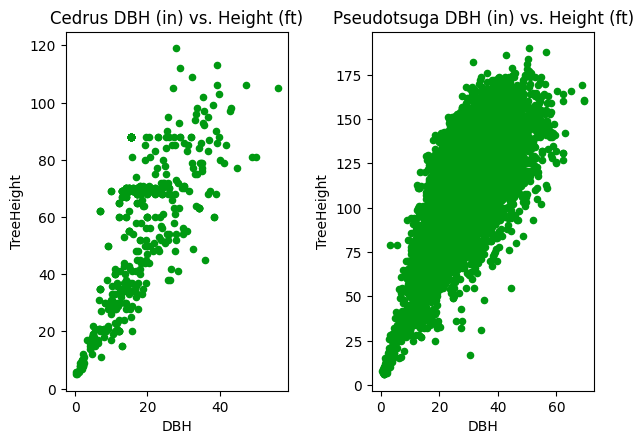

In [ ]:
#clear earlier figure
fig.clear()

#create new figure with 2 subplots
fig, axs = plt.subplots(1,2)

#create two scatter plots of DBH vs Tree Height for Calocedrus trees and Pseudotsuga trees on single figure
cedardf.plot(kind='scatter', x='DBH', y='TreeHeight', title='Cedrus DBH (in) vs. Height (ft)', color="#009911", ax=axs[0])
pseudotsugadf.plot(kind='scatter', x='DBH', y='TreeHeight', title='Pseudotsuga DBH (in) vs. Height (ft)', color="#009911", ax=axs[1])
fig.tight_layout(pad=2.0)
plt.savefig("pseudotsuga_x_cedrus.png")


# **Create figure with four subplots using customer churn data**


['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


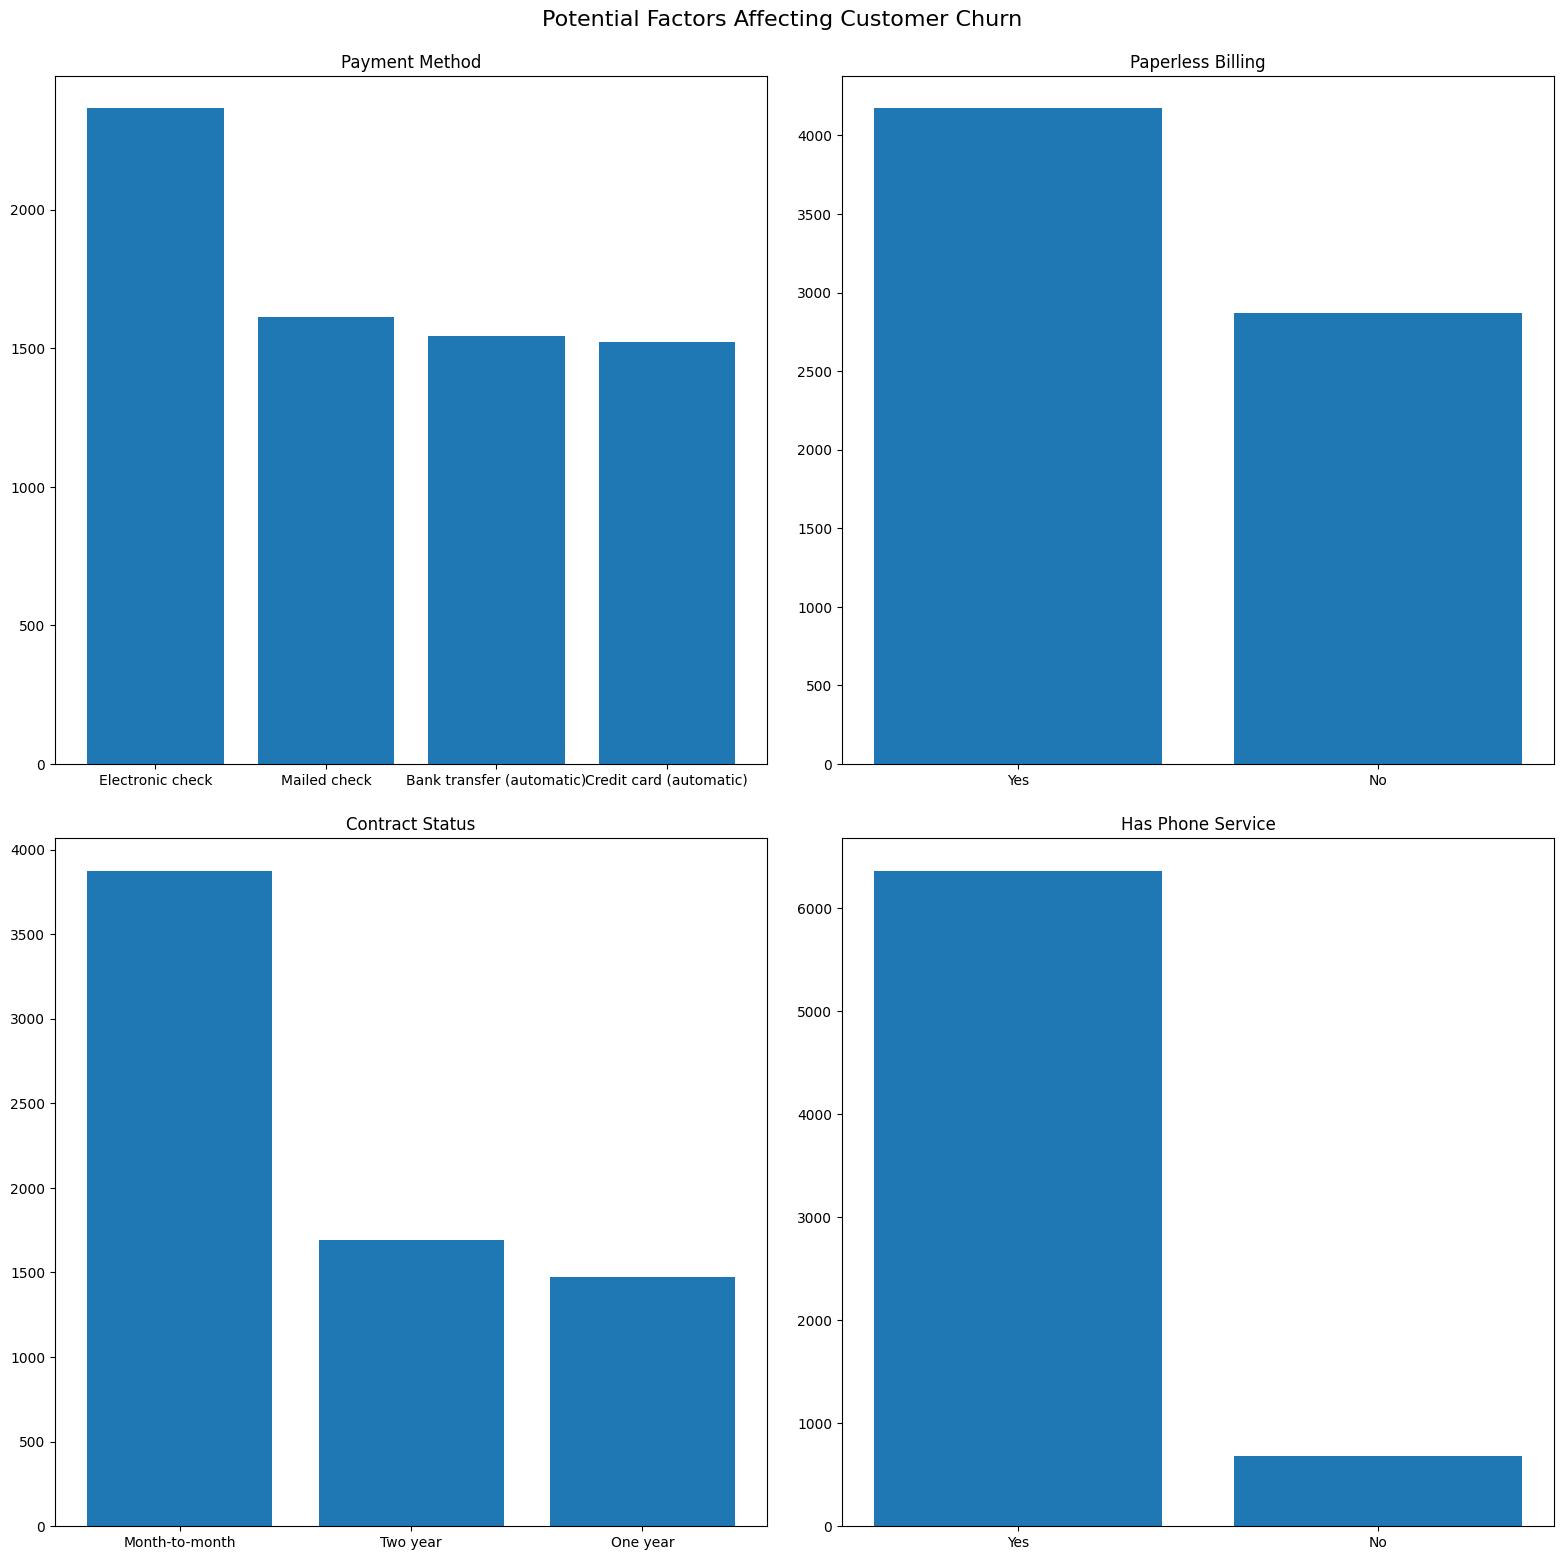

In [ ]:
#create counts for each unique value in the following four columns
valuecountspaymentmethod = customerchurndf['PaymentMethod'].value_counts().to_dict()
valuecountspaperlessbilling = customerchurndf['PaperlessBilling'].value_counts().to_dict()
valuecountscontract = customerchurndf['Contract'].value_counts().to_dict()
valuecountsphoneservice = customerchurndf['PhoneService'].value_counts().to_dict()


#create separate lists of unique values and counts for those unique values
valuecountspaymentmethodk = list([k for k,v in valuecountspaymentmethod.items()])
valuecountspaymentmethodv = list([v for k,v in valuecountspaymentmethod.items()])
valuecountspaperlessbillingk = list([k for k,v in valuecountspaperlessbilling.items()])
valuecountspaperlessbillingv = list([v for k,v in valuecountspaperlessbilling.items()])
valuecountscontractk = list([k for k,v in valuecountscontract.items()])
valuecountscontractv = list([v for k,v in valuecountscontract.items()])
valuecountsphoneservicek = list([k for k,v in valuecountsphoneservice.items()])
valuecountsphoneservicev = list([v for k,v in valuecountsphoneservice.items()])


#create figure with 4 subplots showing counts of unique values across four customer characteristics
print(customerchurndf.columns.to_list())
fig, axs = plt.subplots(2,2,figsize=(16,16))
axs[0,0].bar(valuecountspaymentmethodk, valuecountspaymentmethodv)
axs[0,0].set_title("Payment Method")
axs[0,1].bar(valuecountspaperlessbillingk, valuecountspaperlessbillingv)
axs[0,1].set_title("Paperless Billing")
axs[1,0].bar(valuecountscontractk, valuecountscontractv)
axs[1,0].set_title("Contract Status")
axs[1,1].bar(valuecountsphoneservicek, valuecountsphoneservicev)
axs[1,1].set_title("Has Phone Service")
plt.suptitle("Potential Factors Affecting Customer Churn", fontsize=16)
fig.tight_layout(pad=2.0)
plt.savefig("customerchurn-characteristics-bar-chart-subplots.jpg")
fig.show()




# Create a scatter plot with a regression line

In [ ]:
# Scatter plot with regression line
fig = px.scatter(pdxtreesdf, x='DBH', y='TreeHeight', trendline='ols', trendline_color_override="black", title="Tree Height (ft) vs DBH (in) for Portland, OR Trees")
fig.update_layout(title_x=0.5,title_xanchor='center')

fig.show()
# fig.write_image("regressionexample1.png")


# **Python for Data Visualization**

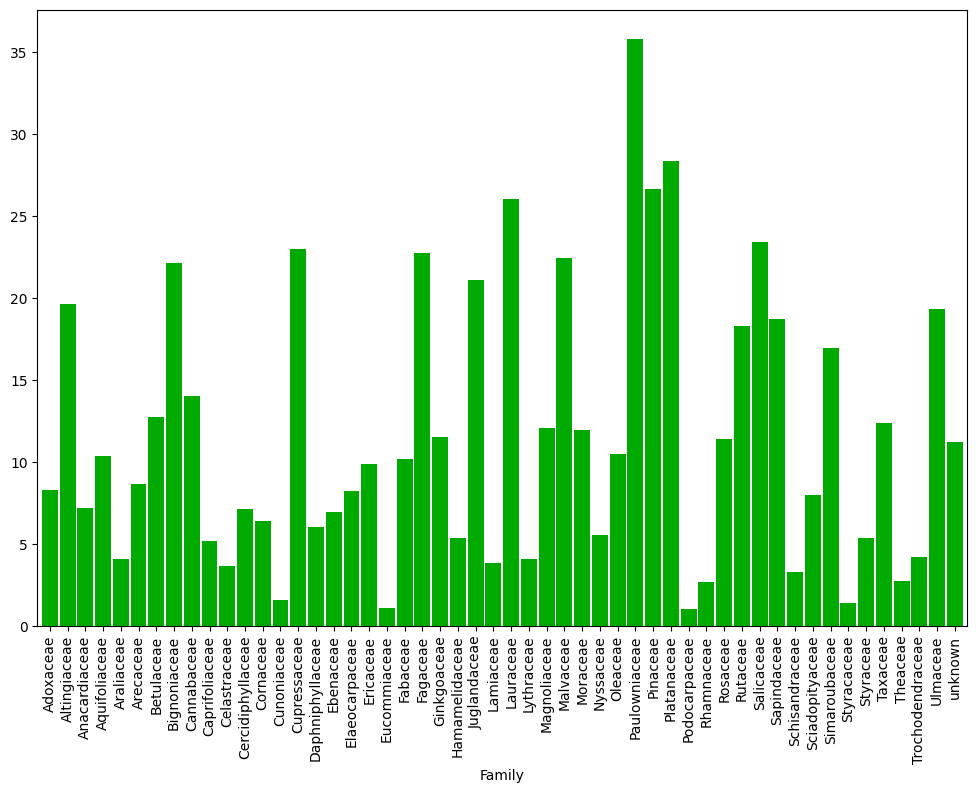

In [ ]:
#create set of unique
uniquepdxtrees = set(pdxtreesdf['Species'].items())

# Group by species and get the value counts for names
treespeciescounts = pdxtreesdf.groupby('Family')['DBH'].mean()

# print(treespeciescounts)

treespeciescounts.plot(kind="bar", width=.9, figsize=(12,8), color="#00aa00")
plt.savefig("example2.jpg")



### Matplotlib Histogram

Text(0, 0.5, 'Count')

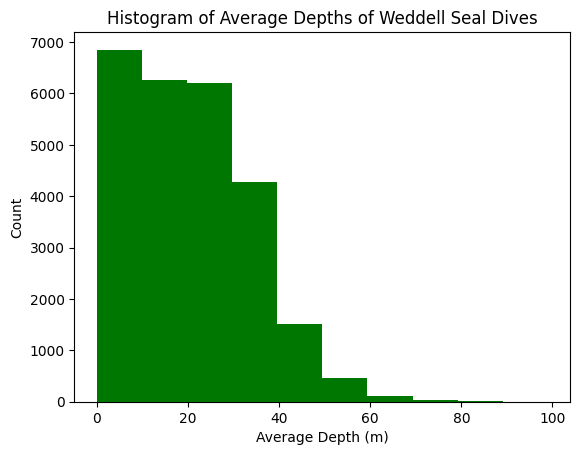

In [ ]:
# plt.bar(avgdepthlist,  label="Average Weddell Seal Dive Depth (m)")
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
n, bins, patches = ax.hist(pdxtreesdf['DBH'].to_list(), bins=10, range=(min(pdxtreesdf['DBH'].to_list()), max(pdxtreesdf['DBH'].to_list())), histtype='bar')

for patch in patches:
    patch.set_facecolor('#007700')

plt.title('Histogram of Average Depths of Weddell Seal Dives')
plt.xlabel('Average Depth (m)')
plt.ylabel('Count')


### Plotly Histogram

In [ ]:
#DIAMETER is in inches
fig = px.histogram(pdxtreesdf, x="DBH", nbins = 25, title="Histogram of Tree Trunk Diameters (in)")
fig.show()

### Plotting Data in 3 Dimensions

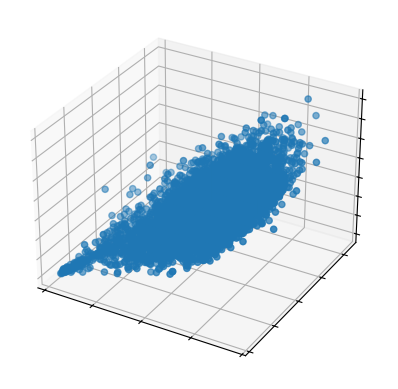

In [ ]:

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(pseudotsugadf['TreeHeight'], pseudotsugadf['DBH'], pseudotsugadf['CrownWidthEW'])

ax.set(xticklabels=[],
       yticklabels=[],
       zticklabels=[])

plt.show()


### Plotting Data in 3 Dimensions with Interactive Visualization

In [ ]:
xs=pseudotsugadf['TreeHeight']
ys=pseudotsugadf['DBH']
zs=pseudotsugadf['CrownWidthEW']
fig = px.scatter_3d(pseudotsugadf, x='TreeHeight', y='DBH', z='CrownWidthEW',color='Condition')
fig.show()

### Matplotlib Venn Diagram

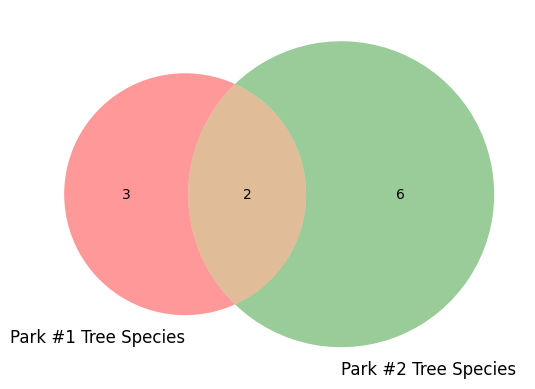

In [ ]:
set1 = set(["Quercus virginiana","Quercus macrocarpa","Celtis laevigata","Carya illinoensis","Quercus shumardii"])
set2 = set(["Carya illinoensis","Quercus macrocarpa","Fraxinus albicans","Taxodium mucronatum", "Acer saccharinum", "Lagerstroemia indica", "Quercus laceyii","Quercus polymorpha"])

matplotlib_venn.venn2([set1, set2], ('Park #1 Tree Species', 'Park #2 Tree Species'))


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning:

Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.



Total green band pixel count = 2080000

Preview of NumPy array of digital numbers that make up the data of the green band image
[[17728 19200 20096 ... 18752 17600 14592]
 [18432 17536 19392 ... 17856 17856 17536]
 [17600 17664 19008 ... 13504 15424 17728]
 ...
 [14592 12736 11200 ... 11136 11904 12352]
 [19392 16768 11840 ... 11136 11776 12288]
 [17600 15872 11904 ... 11328 11008 10496]]


View of the green band image


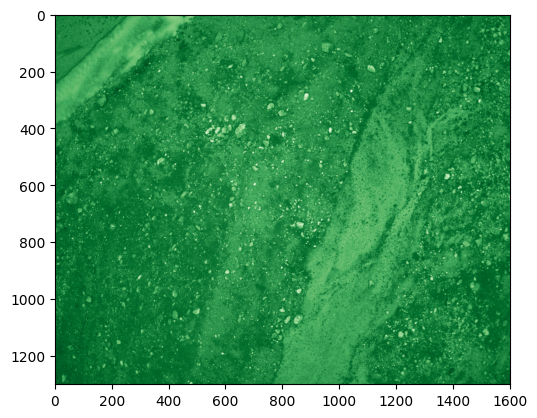



Histogram of digital number values in the green band image


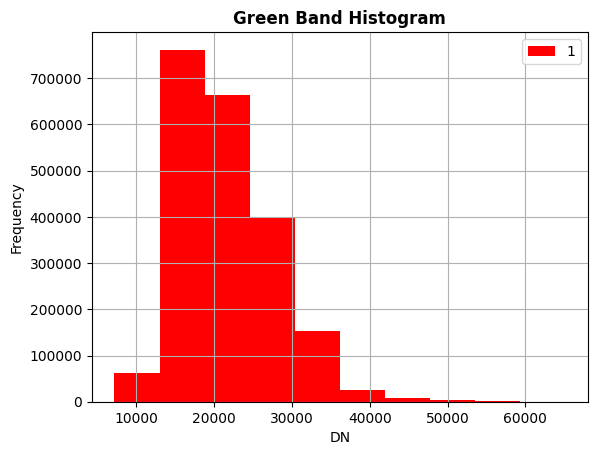

In [ ]:
bandgreen = rasterio.open(singleimageband2['url'])

totalbandgreenpixelcount = bandgreen.shape[0] * bandgreen.shape[1]
print("Total green band pixel count = " + str(totalbandgreenpixelcount))
print()

print("Preview of NumPy array of digital numbers that make up the data of the green band image")
print(bandgreen.read(1))
print("\n")

print("View of the green band image")
rasterio.plot.show(bandgreen,cmap="Greens_r")
print("\n")

print("Histogram of digital number values in the green band image")
rasterio.plot.show_hist(bandgreen, bins=10, masked=True, title='Green Band Histogram', ax=None, label=None)

Red band array of digital numbers
[[19072 18880 18752 ... 14656 15808 16896]
 [18752 20416 19008 ... 12352 13952 14784]
 [19776 19136 19456 ... 11264 12352 13952]
 ...
 [12352 16512 20224 ...  8832  9088  9344]
 [11264 15680 18112 ...  9280  9344  9216]
 [ 9664 12864 15424 ...  8832  9024  9088]]

NIR band array of digital numbers
[[13824 13568 14336 ... 15168 15680 15232]
 [13440 13504 14400 ... 14976 16192 16384]
 [13760 14208 14144 ... 16128 17088 16576]
 ...
 [21632 20608 23616 ... 29824 27392 25664]
 [21824 21696 21632 ... 29312 27456 23872]
 [20096 20928 22528 ... 26368 22784 20032]]

Resulting NDVI array of digital numbers
[[-0.15953307 -0.16370809 -0.13346228 ...  0.01716738 -0.00406504
  -0.05179283]
 [-0.16500994 -0.20377358 -0.13793103 ...  0.09601874  0.07430998
   0.0513347 ]
 [-0.17938931 -0.14779271 -0.15809524 ...  0.17757009  0.16086957
   0.08595388]
 ...
 [ 0.27306968  0.11034483  0.07737226 ...  0.54304636  0.50175439
   0.46617916]
 [ 0.31914894  0.1609589   0.0885

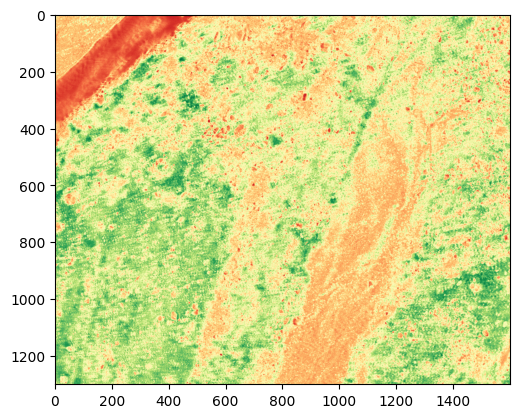

In [ ]:
with rasterio.open(singleimageband3['url']) as imagefile:
  bandred = imagefile.read(1)
  # plt.imshow(imagedata, cmap=singleimageband1['cmap'])

  with rasterio.open(singleimageband5['url']) as imagefiletwo:
    bandnir = imagefiletwo.read(1)
    # plt.imshow(imagedata, cmap=singleimageband2['cmap'])

    print("Red band array of digital numbers")
    print(bandred)
    print()
    print("NIR band array of digital numbers")
    print(bandnir)
    print()

    #Allow division by zero
    np.seterr(divide='ignore', invalid='ignore')

    totalnirpixelcount = bandnir.shape[0] * bandnir.shape[1]

    # Calculate NDVI
    ndvi = (bandnir.astype(float) - bandred.astype(float)) / (bandnir.astype(float) + bandred.astype(float))

    print("Resulting NDVI array of digital numbers")
    print(ndvi)
    print()

    # Count the occurance of NoData values in np array
    vegetationpixelcount = np.count_nonzero(ndvi > 0.071)

    # Get a total pixel count
    total_count = ndvi.shape[0] * ndvi.shape[1]

    # Get a % of NoData pixels
    val = vegetationpixelcount/total_count * 100

    # ndvi[ndvi > .071] = 1
    # ndvi[ndvi == .071] = 1
    # ndvi[ndvi < .071] = 0

    #display one band:
    plt.imshow(ndvi, cmap="RdYlGn")